In [1]:
import requests
from bs4 import BeautifulSoup
from pandas import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
pd.DataFrame()

""


In [4]:
url = "https://books.toscrape.com/"
headers = {
    "User-Agent": "Mozilla/5.0"
}  #притворяемся браузером
response =requests.get(url, headers=headers, timeout=10)

html= response.text 
html[:300] #выводим 300 символов

'<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lan'

In [5]:
response.status_code == 200

True

In [6]:
len(html)

51294

In [7]:
soup = BeautifulSoup(html, "html.parser") #создаём дерево
soup

<!DOCTYPE html>

<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en-us"> <!--<![endif]-->
<head>
<title>
    All products | Books to Scrape - Sandbox
</title>
<meta content="text/html; charset=utf-8" http-equiv="content-type"/>
<meta content="24th Jun 2016 09:29" name="created"/>
<meta content="" name="description"/>
<meta content="width=device-width" name="viewport"/>
<meta content="NOARCHIVE,NOCACHE" name="robots"/>
<!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
<!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
<link href="static/oscar/favicon.ico" rel="shortcut icon"/>
<link href="static/oscar/css/styles.css" rel="stylesheet" type="text/css"/>
<link href="s

In [8]:
#первый тег <h3>;
soup.find('h3')

<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>

In [9]:
#первый тег <p>;
soup.find('p')

<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>

In [10]:
#все теги <article>.
soup.find_all('article')

[<article class="product_pod">
 <div class="image_container">
 <a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
 </div>
 <p class="star-rating Three">
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 </p>
 <h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
 <div class="product_price">
 <p class="price_color">Â£51.77</p>
 <p class="instock availability">
 <i class="icon-ok"></i>
     
         In stock
     
 </p>
 <form>
 <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
 </form>
 </div>
 </article>,
 <article class="product_pod">
 <div class="image_container">
 <a href="catalogue/tipping-the-velvet_999/index.html"><img alt="Tipping the Velvet" class="th

In [12]:
len(soup.find_all('article'))

20

In [25]:
#наёдём один товар и разберём его структура
book = soup.find("article", class_="product_pod")
title = book.find("h3").find("a").get('title')
href = book.find("h3").find("a").get('href')
price = book.find("p", class_="price_color").get_text()
stock = book.find("p", class_="instock availability").get_text(strip=True)
rating = book.find("p", class_="star-rating").get('class')[-1]
{'title':title,
 'href':href,
 'price':price,
 'stock':stock,
 'rating':rating}

{'title': 'A Light in the Attic',
 'href': 'catalogue/a-light-in-the-attic_1000/index.html',
 'price': 'Â£51.77',
 'stock': 'In stock',
 'rating': 'Three'}

In [29]:
#найдём все карточки товаров: список словарей
books_data = []
for book in soup.find_all("article", class_="product_pod"):
    title = book.find("h3").find("a").get('title')
    href = book.find("h3").find("a").get('href')
    price = book.find("p", class_="price_color").get_text()
    stock = book.find("p", class_="instock availability").get_text(strip=True)
    rating = book.find("p", class_="star-rating").get('class')[-1]
    books_data.append({'title':title,
     'href':href,
     'price':price,
     'stock':stock,
     'rating':rating})
books_data[:3]

[{'title': 'A Light in the Attic',
  'href': 'catalogue/a-light-in-the-attic_1000/index.html',
  'price': 'Â£51.77',
  'stock': 'In stock',
  'rating': 'Three'},
 {'title': 'Tipping the Velvet',
  'href': 'catalogue/tipping-the-velvet_999/index.html',
  'price': 'Â£53.74',
  'stock': 'In stock',
  'rating': 'One'},
 {'title': 'Soumission',
  'href': 'catalogue/soumission_998/index.html',
  'price': 'Â£50.10',
  'stock': 'In stock',
  'rating': 'One'}]

In [30]:
pd.DataFrame(books_data).head()

,title,href,price,stock,rating
0,A Light in the Attic,catalogue/a-light-in-the-attic_1000/index.html,Â£51.77,In stock,Three
1,Tipping the Velvet,catalogue/tipping-the-velvet_999/index.html,Â£53.74,In stock,One
2,Soumission,catalogue/soumission_998/index.html,Â£50.10,In stock,One
3,Sharp Objects,catalogue/sharp-objects_997/index.html,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,catalogue/sapiens-a-brief-history-of-humankind...,Â£54.23,In stock,Five


In [32]:
books_df.shape

(20, 5)

In [33]:
books_df.dtypes

title     str
href      str
price     str
stock     str
rating    str
dtype: object

In [34]:
books_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   20 non-null     str  
 1   href    20 non-null     str  
 2   price   20 non-null     str  
 3   stock   20 non-null     str  
 4   rating  20 non-null     str  
dtypes: str(5)
memory usage: 932.0 bytes


In [41]:
books_df['price_gbp'] = books_df['price'].str.replace('Â£','').astype(float)
books_df['price_gbp'] = books_df['price'].str[2:].astype(float)
books_df['price_gbp'] = books_df['price'].str.replace(r'\D','',regex=True).astype(float)/100
books_df.head()

,title,href,price,stock,rating,price_gbp,rating_num
0,A Light in the Attic,catalogue/a-light-in-the-attic_1000/index.html,Â£51.77,In stock,Three,51.77,3
1,Tipping the Velvet,catalogue/tipping-the-velvet_999/index.html,Â£53.74,In stock,One,53.74,1
2,Soumission,catalogue/soumission_998/index.html,Â£50.10,In stock,One,50.10,1
3,Sharp Objects,catalogue/sharp-objects_997/index.html,Â£47.82,In stock,Four,47.82,4
4,Sapiens: A Brief History of Humankind,catalogue/sapiens-a-brief-history-of-humankind...,Â£54.23,In stock,Five,54.23,5


In [42]:
pd.factorize(books_df.rating)

(array([0, 1, 1, 2, 3, 1, 2, 0, 2, 1, 4, 2, 3, 3, 3, 0, 1, 1, 4, 4]),
 Index(['Three', 'One', 'Four', 'Five', 'Two'], dtype='str'))

In [43]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}
books_df['rating_num'] = books_df['rating'].map(rating_map)
books_df.head()

,title,href,price,stock,rating,price_gbp,rating_num
0,A Light in the Attic,catalogue/a-light-in-the-attic_1000/index.html,Â£51.77,In stock,Three,51.77,3
1,Tipping the Velvet,catalogue/tipping-the-velvet_999/index.html,Â£53.74,In stock,One,53.74,1
2,Soumission,catalogue/soumission_998/index.html,Â£50.10,In stock,One,50.10,1
3,Sharp Objects,catalogue/sharp-objects_997/index.html,Â£47.82,In stock,Four,47.82,4
4,Sapiens: A Brief History of Humankind,catalogue/sapiens-a-brief-history-of-humankind...,Â£54.23,In stock,Five,54.23,5


In [44]:
books_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       20 non-null     str    
 1   href        20 non-null     str    
 2   price       20 non-null     str    
 3   stock       20 non-null     str    
 4   rating      20 non-null     str    
 5   price_gbp   20 non-null     float64
 6   rating_num  20 non-null     int64  
dtypes: float64(1), int64(1), str(5)
memory usage: 1.2 KB


In [48]:
#Поиск элементов чрезе CSS-секлекторы
first_book = soup.select_one("article.product_pod")
first_book.select_one('h3 a').get('title')

'A Light in the Attic'

In [49]:
first_book.select_one('p.price_color').get_text()

'Â£51.77'

In [50]:
for i in range(1,6):
    print(f'https://books.toscrape.com/catalogue/page-{i}.html')

https://books.toscrape.com/catalogue/page-1.html
https://books.toscrape.com/catalogue/page-2.html
https://books.toscrape.com/catalogue/page-3.html
https://books.toscrape.com/catalogue/page-4.html
https://books.toscrape.com/catalogue/page-5.html


In [57]:
#пагинация
def parse_books_page(page_html):
    soup = BeautifulSoup(page_html,'html.parser')   
    books_data = []
    for book in soup.find_all("article", class_="product_pod"):
        title = book.find("h3").find("a").get('title')
        href = book.find("h3").find("a").get('href')
        price = book.find("p", class_="price_color").get_text()
        stock = book.find("p", class_="instock availability").get_text(strip=True)
        rating = book.find("p", class_="star-rating").get('class')[-1]
        books_data.append({'title':title,
         'href':href,
         'price':price,
         'stock':stock,
         'rating':rating})
    return books_data
parse_books_page(html)[:1]

[{'title': 'A Light in the Attic',
  'href': 'catalogue/a-light-in-the-attic_1000/index.html',
  'price': 'Â£51.77',
  'stock': 'In stock',
  'rating': 'Three'}]

In [59]:
all_data = []
for i in range(1,51):
    url=f'https://books.toscrape.com/catalogue/page-{i}.html'
    #print(f'https://books.toscrape.com/catalogue/page-{i}.html')
    response = requests.get(url,headers=headers,timeout=10)
    if response.status_code == 200:
        all_data.extend(parse_books_page(response.text))
    time.sleep(0.1)
len(all_data)

1000

In [63]:
#Извлекаем данные
df = pd.DataFrame(all_data)
df['price_gbp'] = df['price'].str[2:].astype(float)
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}
df['rating_num'] = df['rating'].map(rating_map)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       1000 non-null   str    
 1   href        1000 non-null   str    
 2   price       1000 non-null   str    
 3   stock       1000 non-null   str    
 4   rating      1000 non-null   str    
 5   price_gbp   1000 non-null   float64
 6   rating_num  1000 non-null   int64  
dtypes: float64(1), int64(1), str(5)
memory usage: 54.8 KB


In [64]:
#количество товаров;
#минимальную цену;
#максимальную цену;
#среднюю цену;
#медианную цену;
df['price_gbp'].describe()

count    1000.00000
mean       35.07035
std        14.44669
min        10.00000
25%        22.10750
50%        35.98000
75%        47.45750
max        59.99000
Name: price_gbp, dtype: float64

<Axes: >

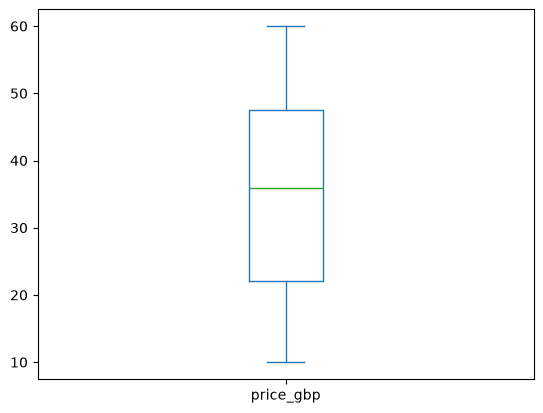

In [65]:
df['price_gbp'].plot(kind='box')

In [66]:
#количество товаров каждого рейтинга через value_counts();
df.rating.value_counts()

rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64

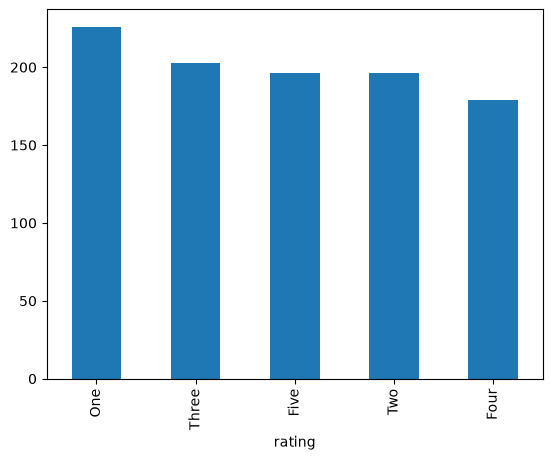

In [67]:
df.rating.value_counts().plot(kind='bar');

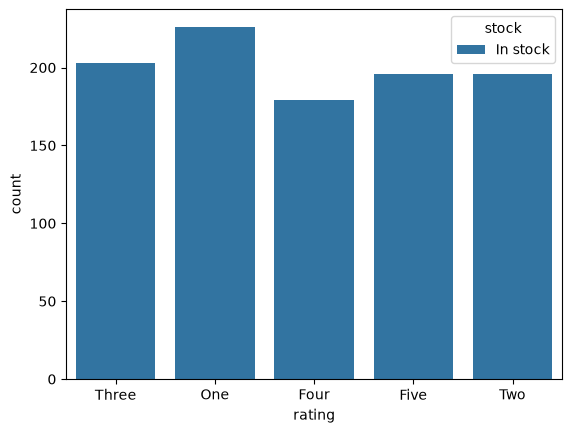

In [68]:
sns.countplot(df,x='rating',hue='stock');

In [69]:
#количество товаров дороже средней цены;
(df['price_gbp']>df['price_gbp'].mean()).sum()

np.int64(513)

In [70]:
len(df[df['price_gbp']>df['price_gbp'].mean()])

513

In [71]:
#среднюю цену товаров с рейтингом 5.
df[df['rating_num']==5]['price_gbp'].mean()

np.float64(35.374489795918365)

In [72]:
df[df['rating_num']==5]['price_gbp'].describe()

count    196.000000
mean      35.374490
std       15.050722
min       10.000000
25%       21.022500
50%       36.900000
75%       49.002500
max       59.920000
Name: price_gbp, dtype: float64

In [73]:
df.groupby('rating_num')['price_gbp'].describe()

,count,mean,std,min,25%,50%,75%,max
rating_num,,,,,,,,
1,226.0,34.561195,13.952258,10.40,22.2425,34.770,45.9175,59.64
2,196.0,34.810918,13.607017,10.02,23.8500,36.215,46.2500,59.95
3,203.0,34.692020,14.696649,10.16,22.1600,33.780,47.8100,59.99
4,179.0,36.093296,15.081276,10.01,21.9150,37.800,49.4450,59.45
5,196.0,35.374490,15.050722,10.00,21.0225,36.900,49.0025,59.92


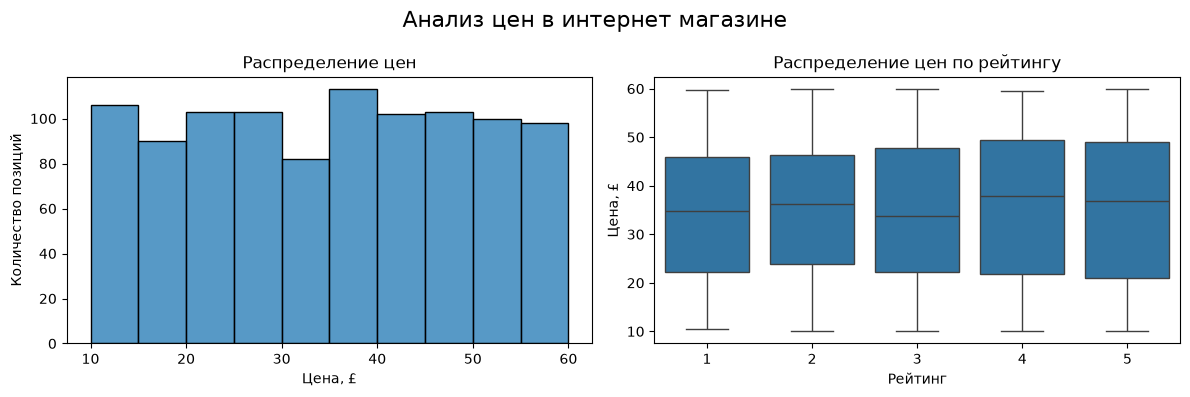

In [78]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)
sns.histplot(df.price_gbp,bins=10,ax=axes[0])
axes[0].set_title('Распределение цен')
axes[0].set_xlabel('Цена, £')
axes[0].set_ylabel('Количество позиций')

sns.boxplot(df,x='rating_num',y='price_gbp')
axes[1].set_title('Распределение цен по рейтингу')
axes[1].set_xlabel('Рейтинг')
axes[1].set_ylabel('Цена, £')

fig.suptitle('Анализ цен в интернет магазине',fontsize=16)
plt.tight_layout()

In [80]:
conda install openpyxl

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: ...working... done
Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\User\anaconda3

  added / updated specs:
    - openpyxl


The following NEW packages will be INSTALLED:

  et_xmlfile         pkgs/main/win-64::et_xmlfile-2.0.0-py314haa95532_0 
  openpyxl           pkgs/main/win-64::openpyxl-3.1.5-py314h827c3e9_1 



Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done

Channel "defaults" has the following notices:
  [info] -- Thu Aug  6 00:00:00 2026
  main-x (Anaconda's new authenticated channel) is now generally available, with thousands of additional packages from our secure supply chain. Get started at: https://anaconda.com/docs/getting-started/main-x?utm_source=channel_notices


Note: you may need to restart the kernel to use updated packages.


In [82]:
#Сформируем итоговый DataFrame
books_market_data = df[['title','price_gbp','stock','rating_num']].sort_values('price_gbp',ascending=False)
books_market_data.head(2)
books_market_data.to_csv('books_market_data.csv')
books_market_data.to_excel('books_market_data.xlsx',index=False)